# Source E — Key Findings: IRS Statistics of Income Panel Data

This notebook shows the most important, already-verified results from
`analysis-output/source-e/source-e-findings.md`. It loads existing computed
artifacts (`source_e_stats.json`, saved figures, capital-composition/
crossvalidation CSVs) rather than recomputing anything.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent.parent if Path.cwd().name == "source-e" else Path.cwd()
FIGURES_DIR = REPO_ROOT / "analysis-output" / "source-e" / "figures"

with open(REPO_ROOT / "analysis-output" / "source-e" / "source_e_stats.json") as f:
    stats = json.load(f)
stats

{'total_counties': 3143,
 'ratio_stats': {'mean': 0.10745513816041805,
  'median': 0.08224652238595272,
  'max': 2.798465773124988,
  'min': 0.0},
 'top_county': 'Teton County, Wyoming',
 'capital_to_wage_ratio_vs_unemployment_velocity_corr': -0.029661513224496092,
 'capital_to_wage_ratio_vs_unemployment_velocity_p': 0.112,
 'capital_to_wage_ratio_vs_gdp_velocity_pct_corr': 0.07052957196710882,
 'capital_to_wage_ratio_vs_gdp_velocity_pct_p': 0.002,
 'gdp_velocity_pct_by_capital_quartile': {'1': 0.01605548089460758,
  '2': 0.018046638435241083,
  '3': 0.020306659654551536,
  '4': 0.02282329969173673},
 'unemployment_velocity_by_capital_quartile': {'1': 0.1771840542832909,
  '2': 0.19749787955894824,
  '3': 0.19859872611464968,
  '4': 0.17039864291772688}}

## 1. Dataset

3,143 of 3,144 US counties/county-equivalents (Kalawao County, HI has no
IRS SOI county-level row at all -- the same gap Source B's QCEW ingestion
independently has), each with wages, qualified dividends, net capital gain,
and the derived `capital_to_wage_ratio`, for Tax Year 2022. Pulled directly
from `irs.gov/pub/irs-soi/22incyallnoagi.csv`, IRS's own pre-aggregated
county-total file (no bot-gating, no per-state download loop needed).

In [2]:
source_e_df = pd.read_parquet(REPO_ROOT / "data" / "source_e_irs_soi.parquet")
print(f"{len(source_e_df):,} counties")
source_e_df[["county_name", "fips_code", "num_returns", "wages_salaries_thousands", "capital_to_wage_ratio"]].head()

3,143 counties


,county_name,fips_code,num_returns,wages_salaries_thousands,capital_to_wage_ratio
0,"Autauga County, Alabama",01001,25750.0,1312069.0,0.040277
1,"Baldwin County, Alabama",01003,113660.0,5786764.0,0.170460
2,"Barbour County, Alabama",01005,9590.0,317614.0,0.079666
3,"Bibb County, Alabama",01007,8220.0,360758.0,0.024429
4,"Blount County, Alabama",01009,24370.0,1123207.0,0.039927


## 2. Finding: Ratio Signal Validates Against Well-Known Resort Geography

The 25 highest-ratio counties are dominated by famous ultra-wealthy resort
and second-home markets: Teton County, WY (Jackson Hole, ratio 2.80, the
national maximum), Pitkin County, CO (Aspen, 1.57), Blaine County, ID (Sun
Valley, 1.24), Collier County, FL (Naples, 1.13), and Monroe County, FL
(Florida Keys, 1.11) top the list -- exactly the county profile the
proposal's "asset-rich, investment-driven markets" framing describes.

In [3]:
capital_composition = pd.read_csv(REPO_ROOT / "outputs" / "source_e_capital_composition.csv")
capital_composition.nlargest(10, "capital_to_wage_ratio")[["county_name", "capital_to_wage_ratio"]]

,county_name,capital_to_wage_ratio
3139,"Teton County, Wyoming",2.798466
294,"Pitkin County, Colorado",1.571092
558,"Blaine County, Idaho",1.243861
332,"Collier County, Florida",1.128669
365,"Monroe County, Florida",1.106065
302,"San Miguel County, Colorado",1.084007
2732,"Shackelford County, Texas",0.996979
351,"Indian River County, Florida",0.973849
371,"Palm Beach County, Florida",0.964405
363,"Martin County, Florida",0.892518


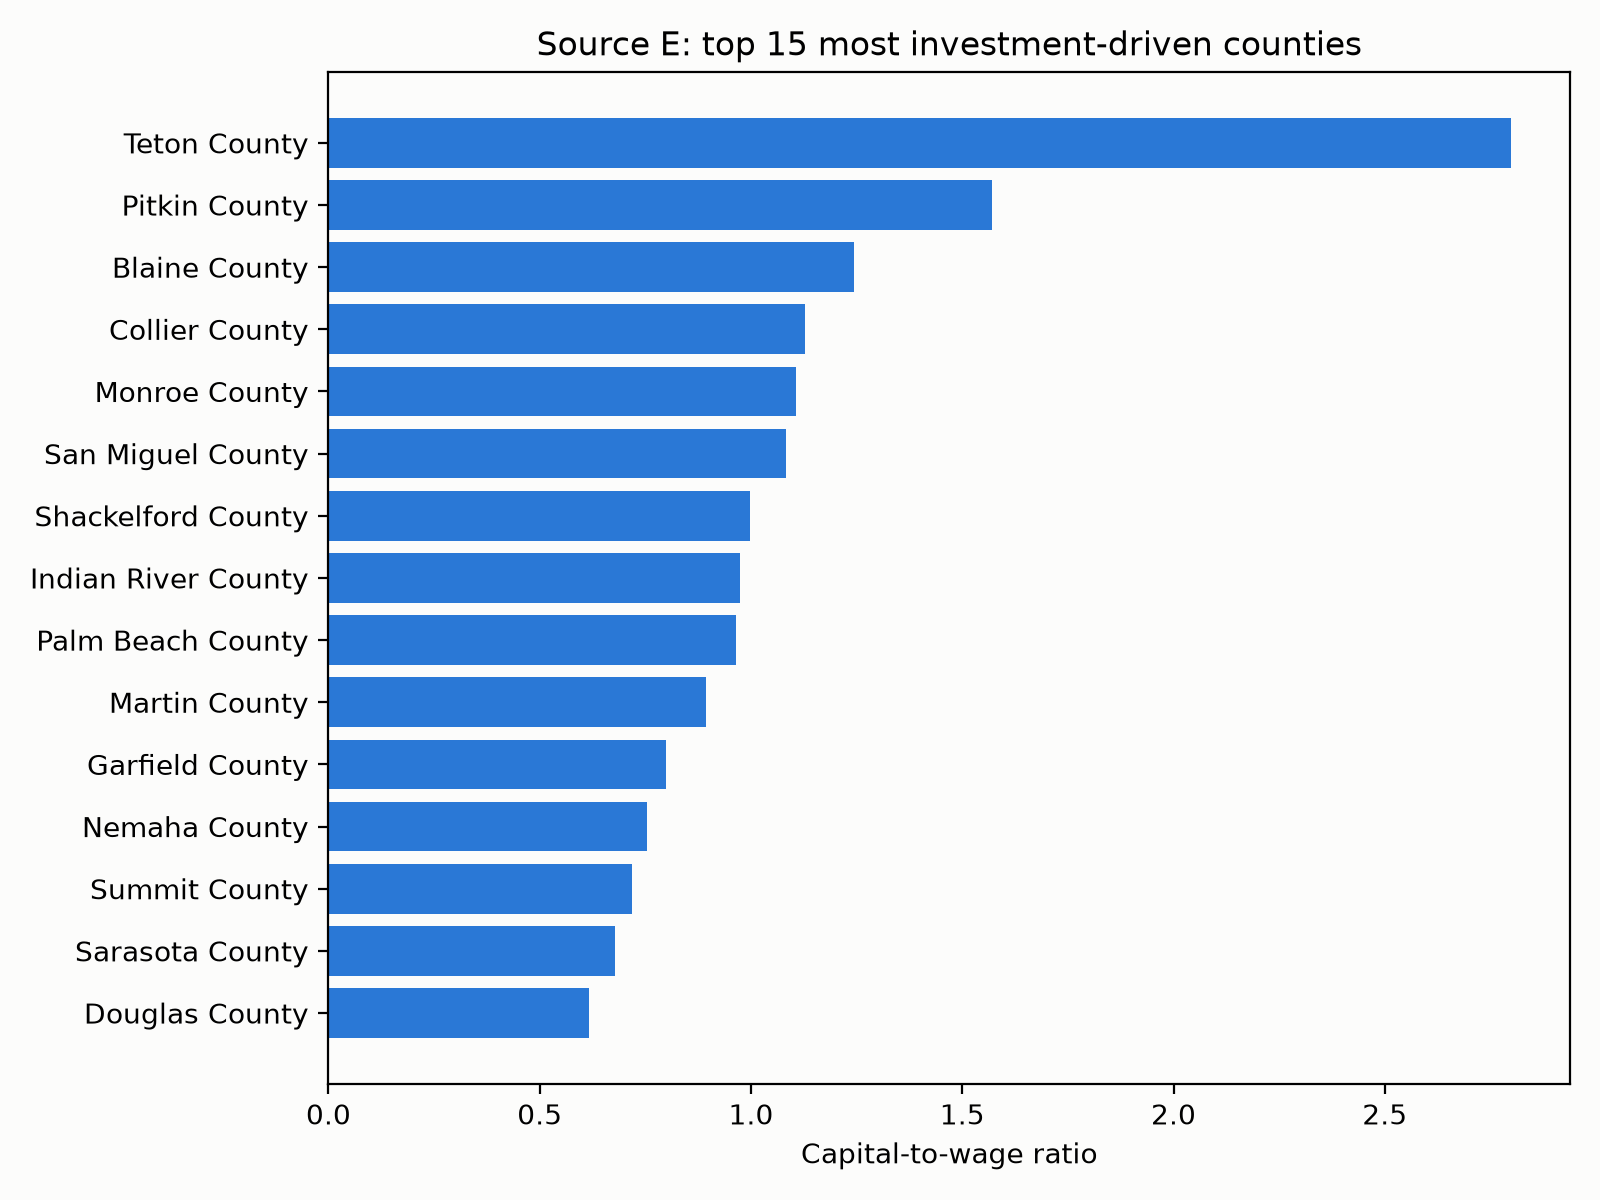

In [4]:
display(Image(filename=str(FIGURES_DIR / "source-e-figure-01-top-investment-driven.png")))

## 3. Finding: No Suppression Flag, Unlike Source B

The Tax Year 2022 documentation guide confirms the IRS applies the same
small-cell privacy suppression BLS QCEW does, but the county file carries
**no disclosure flag at all** -- a suppressed cell and a true zero are both
written as a bare `0`. Three counties (Kenedy, King, and Loving, TX -- all
under 150 total returns) show this exact pattern for capital
gains/dividends and cannot be resolved from this file alone.

In [5]:
zero_ratio = source_e_df[source_e_df["capital_to_wage_ratio"] == 0]
zero_ratio[["county_name", "num_returns", "net_cap_gain_thousands", "qualified_dividends_thousands"]]

,county_name,num_returns,net_cap_gain_thousands,qualified_dividends_thousands
2654,"Kenedy County, Texas",140.0,0.0,0.0
2658,"King County, Texas",100.0,0.0,0.0
2674,"Loving County, Texas",40.0,0.0,0.0


## 4. Finding: Low-Return-Count Noise at the Ratio's Tail

Several counties with fewer than 1,000 total returns also rank in the top
25 by ratio (e.g. Arthur County, NE at 190 returns; Garfield County, MT at
550), each with capital gains several times its dividend total -- the
signature of a small number of large one-time sales (plausibly farm/ranch
land) rather than sustained investment-income exposure. This is a distinct
noise source from the resort-county signal in Section 2.

In [6]:
low_n_high_ratio = source_e_df.nlargest(25, "capital_to_wage_ratio")
low_n_high_ratio[low_n_high_ratio["num_returns"] < 1000][
    ["county_name", "num_returns", "capital_to_wage_ratio"]
]

,county_name,num_returns,capital_to_wage_ratio
1615,"Garfield County, Montana",550.0,0.798304
1713,"McPherson County, Nebraska",210.0,0.593296
1657,"Arthur County, Nebraska",190.0,0.590705
2645,"Jeff Davis County, Texas",910.0,0.586269
2393,"Harding County, South Dakota",590.0,0.508604


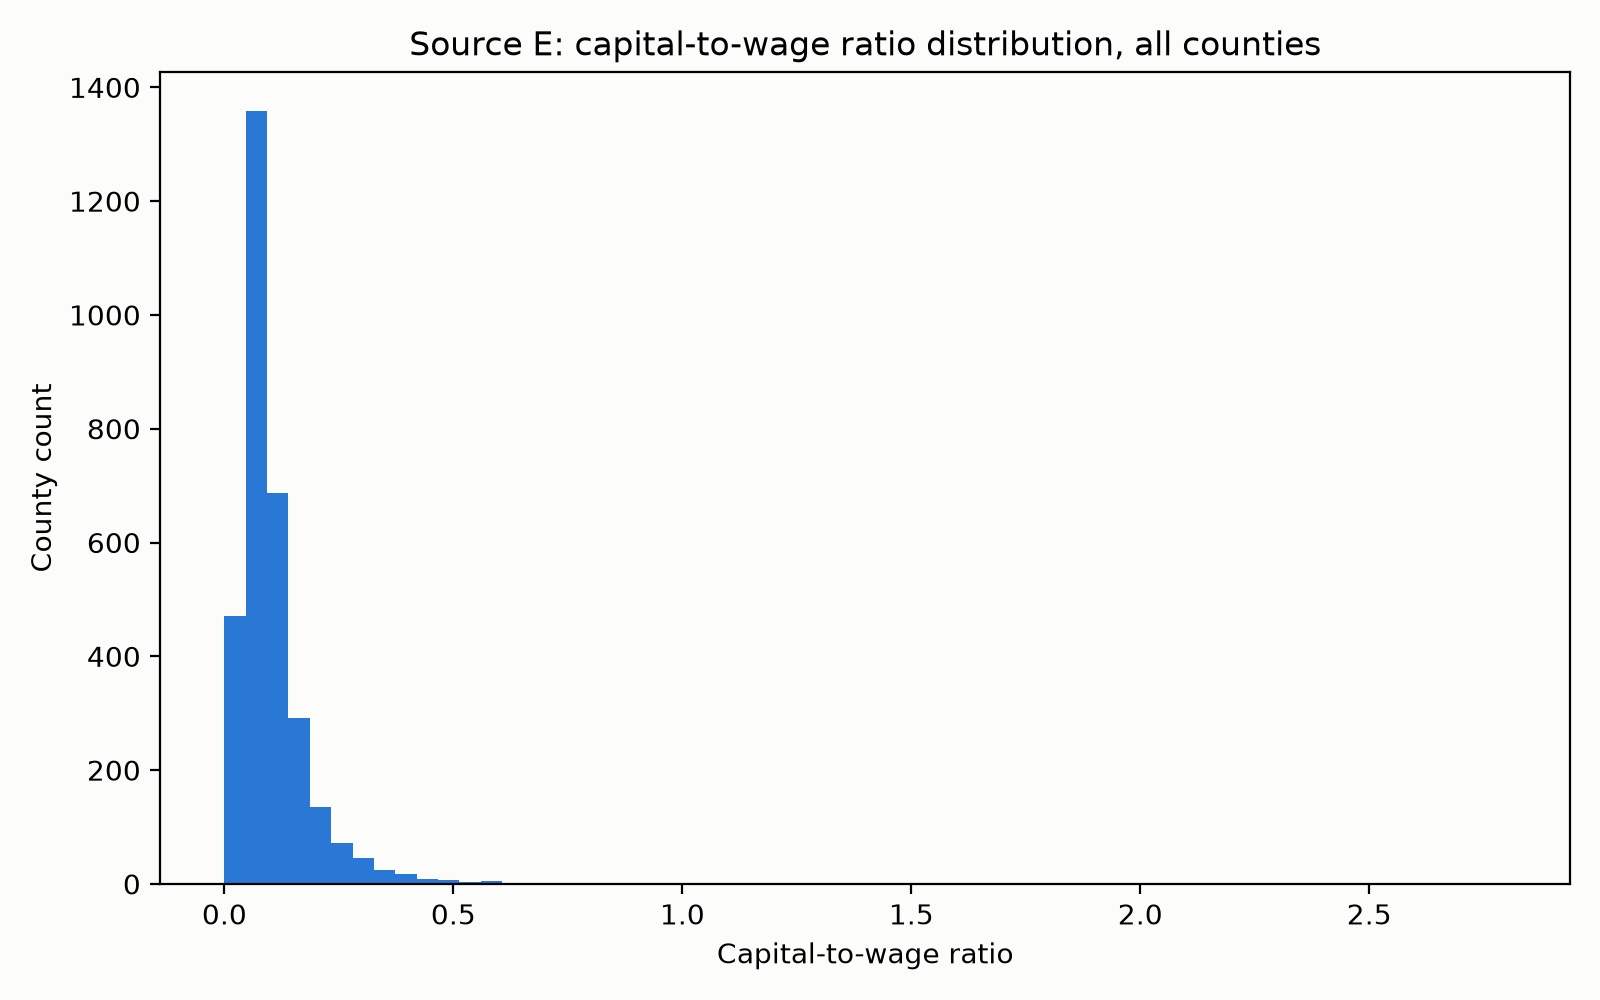

In [7]:
display(Image(filename=str(FIGURES_DIR / "source-e-figure-02-ratio-distribution.png")))

## 5. Finding: Weak GDP-Velocity Link, No Unemployment Link

Cross-validating against Source C: `capital_to_wage_ratio` correlates
weakly but significantly with size-normalized GDP velocity (r=0.071,
p=0.002) and is not significantly related to unemployment velocity
(r=-0.030, p=0.112) -- directionally consistent with the proposal's framing
that investment-heavy counties' wealth is tied to broader market
performance rather than local job survival.

In [8]:
print("capital_to_wage_ratio vs unemployment velocity r =", stats["capital_to_wage_ratio_vs_unemployment_velocity_corr"])
print("capital_to_wage_ratio vs gdp_velocity_pct r =", stats["capital_to_wage_ratio_vs_gdp_velocity_pct_corr"])
print()
pd.Series(stats["gdp_velocity_pct_by_capital_quartile"], name="mean_gdp_velocity_pct")

capital_to_wage_ratio vs unemployment velocity r = -0.029661513224496092
capital_to_wage_ratio vs gdp_velocity_pct r = 0.07052957196710882



1    0.016055
2    0.018047
3    0.020307
4    0.022823
Name: mean_gdp_velocity_pct, dtype: float64

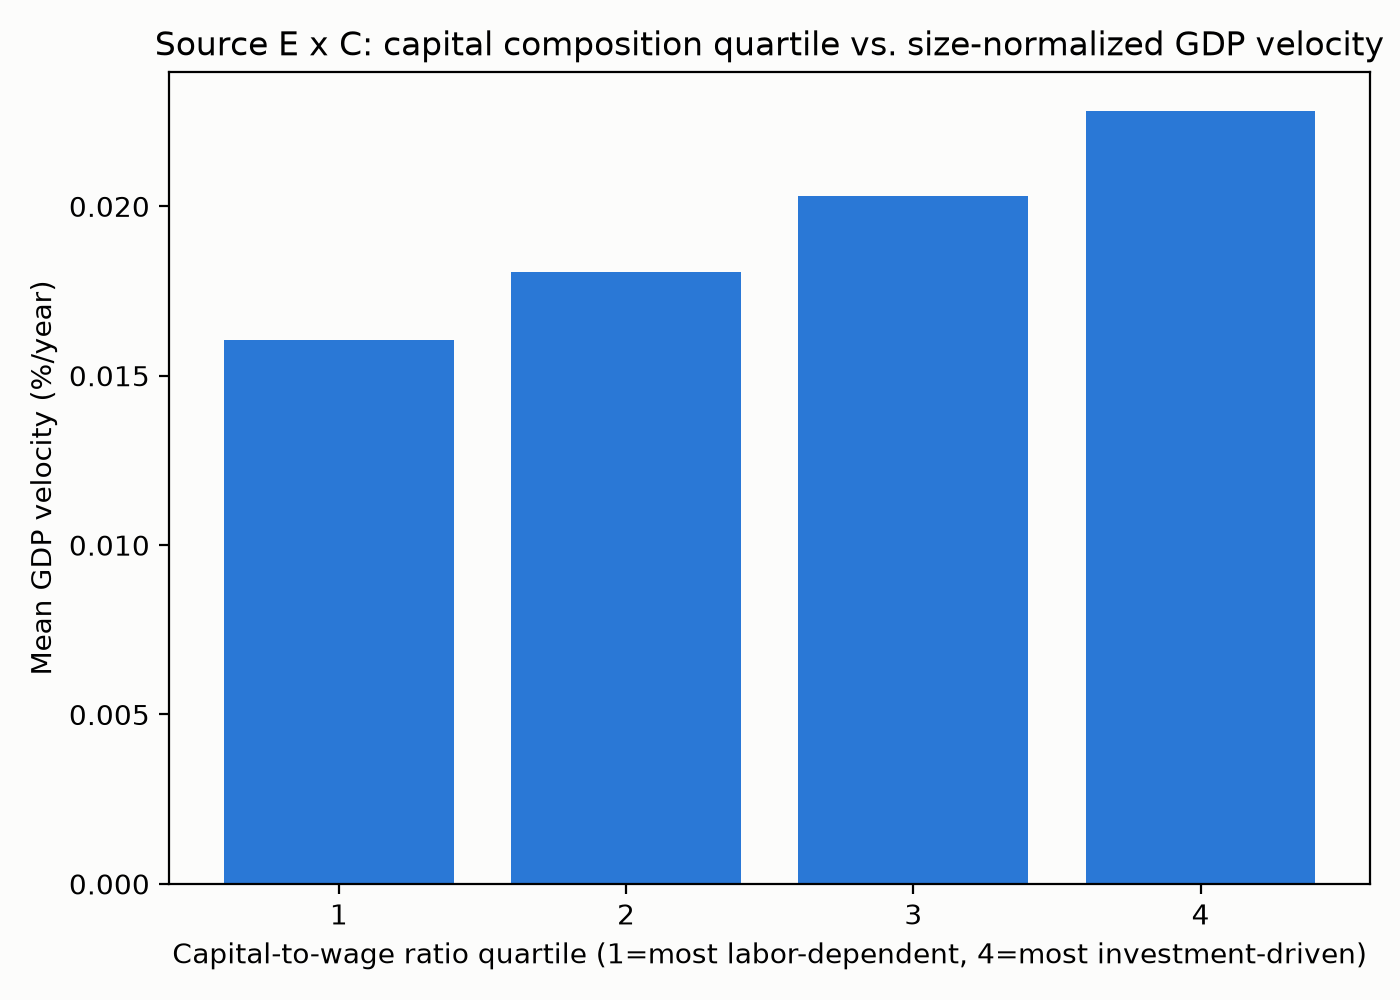

In [9]:
display(Image(filename=str(FIGURES_DIR / "source-e-figure-03-composition-vs-velocity.png")))

## 6. Limitation: Ratio Reliability Depends on Return Count

Sections 3 and 4 both point to the same underlying caveat: `capital_to_wage_ratio`
is most reliable in counties with a large return base, and least reliable
(either fully opaque due to suppression, or noisy due to one-time events)
in very-low-`num_returns` counties. Downstream consumers should consider
weighting or filtering by `num_returns` rather than treating the raw ratio
as equally trustworthy everywhere.

In [10]:
source_e_df["num_returns"].describe()

count    3.143000e+03
mean     5.049570e+04
std      1.609325e+05
min      4.000000e+01
25%      4.690000e+03
50%      1.170000e+04
75%      3.126500e+04
max      4.691250e+06
Name: num_returns, dtype: float64

## 7. Proposal Alignment Summary

See `analysis-output/source-e/source-e-findings.md` section 8 for the full
assessment. Short version: the capital-gains/dividends-to-wages ratio
mechanism works exactly as the proposal describes, the real access
mechanism is simpler than the pre-scoping spec assumed (a direct CSV, no
zip archive), and this round surfaced two new limitations neither scoping
doc anticipated: no suppression flag at all (unlike Source B), and
low-return-count noise inflating the ratio independent of suppression.